# Notebook to align AX3 accelerometer measurements with audio recorded tap hit sequence

Concurrent measurement of measurement across devices is ensured using a tapping protocol to synchronise information per accelerometer sensor with a fixed timeline. This notebook pulls the two tapped timing cues from the audio, finds matching peaks in the accelerometer measurements, corrects the measurements and generates a summary CSV of sensor values resampled to a common set of timestamps with an even sample rate. 

In [2]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from IPython.display import Audio
import mir_eval.sonify


from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d


In [3]:
%load_ext autoreload
%autoreload 1
%aimport al

In [4]:
%reload_ext autoreload

## Load data and timing details

audio file (ZOOM0019_LR.WAV): 
 - Sync 1,  34.319 s, 13:48 local time
 - clapper 1, 2437.788 s,
 - Stimulus (applause), 2505.937s
 - Stimulus (music), 2528.285
 - Stimulus (applause 2), 2822.525
 - clapper 2, 2850.388 s,
 - clapper 3, 2853.664 s
 - Sync 2, 4214.149 s


In [5]:
sync1_start = pd.to_datetime('2025-09-30 13:48:00.000+0200') # as reported to the sync spider
# sync_start 

# Extract sync cues from accompanying audio recording

In [5]:
audio_file ='../Raw/ZOOM0019_LR.WAV'
y, sr = librosa.load(audio_file)
file1_len = len(y)
cues= {}

198450


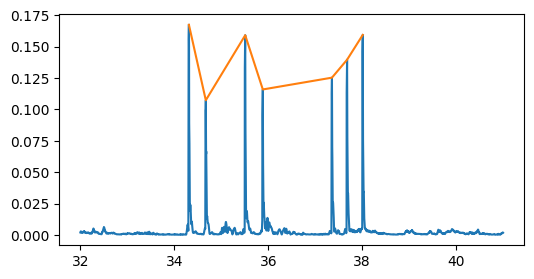

,rms,peaks,DateTime
32.000000,0.001962,0,2025-09-30 13:48:32+02:00
32.002902,0.002395,0,2025-09-30 13:48:32.002902494+02:00
32.005805,0.002703,0,2025-09-30 13:48:32.005804989+02:00
32.008707,0.002713,0,2025-09-30 13:48:32.008707483+02:00
32.011610,0.002548,0,2025-09-30 13:48:32.011609977+02:00
...,...,...,...
40.986122,0.001687,0,2025-09-30 13:48:40.986122449+02:00
40.989025,0.001895,0,2025-09-30 13:48:40.989024943+02:00
40.991927,0.001920,0,2025-09-30 13:48:40.991927438+02:00
40.994830,0.001943,0,2025-09-30 13:48:40.994829932+02:00


In [6]:
cue_delay = 32 # seconds  34.319 
cue_start = cue_delay*sr
cue_end = cue_start + 9*sr
cue = y[cue_start:cue_end]
print(len(cue))

cue_df = al.local_max_max(cue,np.round(cue_delay,3),sr,thresh = 0.98)
cue_df['rms'].plot(figsize=(6,3))
cue_df.loc[cue_df['peaks']==1,'rms'].plot()
plt.show()
cue_df['DateTime'] = sync1_start + pd.to_timedelta(cue_df.index,unit='s')
cue_df

In [7]:
cues['Sync1'] = cue_df.copy()
cue_df.to_csv('./outfiles/cue1.csv')


176400


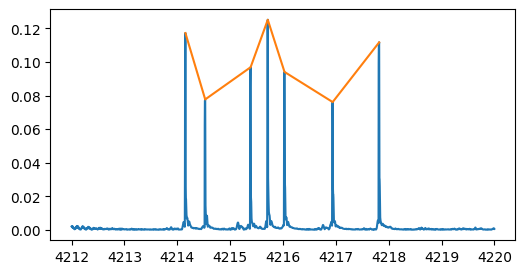

,rms,peaks,DateTime
4212.000000,0.002095,0,2025-09-30 14:58:12+02:00
4212.002902,0.002259,0,2025-09-30 14:58:12.002902494+02:00
4212.005805,0.002271,0,2025-09-30 14:58:12.005804989+02:00
4212.008707,0.001663,0,2025-09-30 14:58:12.008707483+02:00
4212.011610,0.001522,0,2025-09-30 14:58:12.011609977+02:00
...,...,...,...
4219.987664,0.000875,0,2025-09-30 14:58:19.987664399+02:00
4219.990567,0.000919,0,2025-09-30 14:58:19.990566893+02:00
4219.993469,0.000922,0,2025-09-30 14:58:19.993469388+02:00
4219.996372,0.000812,0,2025-09-30 14:58:19.996371882+02:00


In [8]:
cue_delay = 4212# seconds  4214.149
cue_start = cue_delay*sr
cue_end = cue_start + 8*sr
cue = y[cue_start:cue_end]
print(len(cue))

cue_df = al.local_max_max(cue,np.round(cue_delay,3),sr,thresh = 0.98)
cue_df['rms'].plot(figsize=(6,3))
cue_df.loc[cue_df['peaks']==1,'rms'].plot()
plt.show()
cue_df['DateTime'] = sync1_start + pd.to_timedelta(cue_df.index,unit='s')
cue_df

In [9]:
cues['Sync2'] = cue_df.copy()
cue_df.to_csv('./outfiles/cue2.csv')

In [10]:
sf = 400 
synch_times = {}
CueT = {}

34.310385    0.0000
34.670295    0.3599
35.509116    1.1987
35.883537    1.5731
37.355102    3.0447
37.677279    3.3669
38.011066    3.7007
Name: SyncTime, dtype: float64


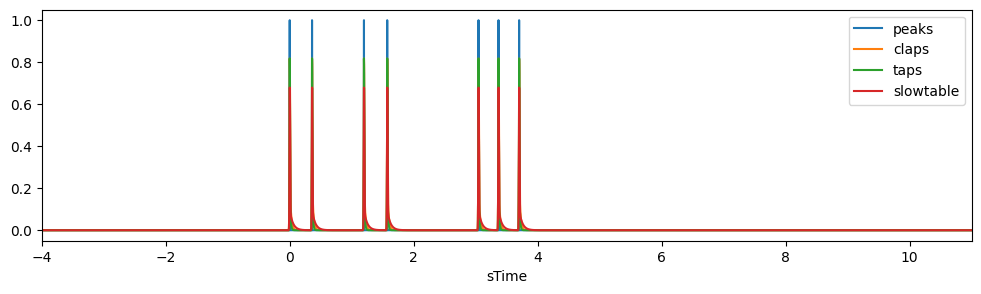

In [11]:
cue_times = cues['Sync1'].copy()
cue_times['DateTime'] = pd.to_datetime(cue_times['DateTime'],format='ISO8601')
cue_times['S_AudioTime'] = np.round(cue_times.index,4)
Sync_Zero_Time_s = cue_times.loc[cue_times['peaks']==1,'S_AudioTime'].iloc[0]
Sync_Zero_Time_dt = cue_times.loc[cue_times['peaks']==1,'DateTime'].iloc[0].tz_localize(None) 
synch_times['cue1'] = Sync_Zero_Time_dt
cue_times['SyncTime'] = cue_times['S_AudioTime']-Sync_Zero_Time_s # zero on onset of first synch cue
peak_times = cue_times.loc[cue_times['peaks']==1,'SyncTime']
print(peak_times)
t_range= [-4,11]
cue = al.cue_template_make(peak_times,sf,t_range)
cue.plot(x='sTime',y=['peaks','claps','taps','slowtable'],figsize=[12,3])
plt.xlim(t_range)

CueT['cue1'] = cue

4214.153651    0.0000
4214.528073    0.3744
4215.387211    1.2335
4215.712290    1.5586
4216.028662    1.8750
4216.940045    2.7863
4217.819501    3.6658
Name: SyncTime, dtype: float64


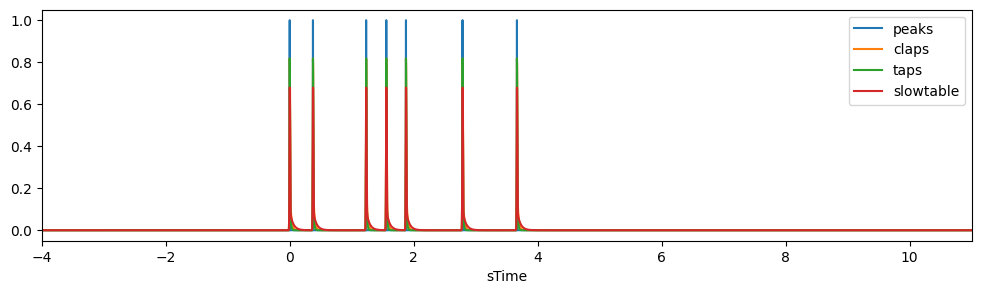

In [12]:
cue_times = cues['Sync2'].copy()
cue_times['DateTime'] = pd.to_datetime(cue_times['DateTime'],format='ISO8601')
cue_times['S_AudioTime'] = np.round(cue_times.index,4)
Sync_Zero_Time_s = cue_times.loc[cue_times['peaks']==1,'S_AudioTime'].iloc[0]
Sync_Zero_Time_dt = cue_times.loc[cue_times['peaks']==1,'DateTime'].iloc[0].tz_localize(None) 
synch_times['cue2'] = Sync_Zero_Time_dt
cue_times['SyncTime'] = cue_times['S_AudioTime']-Sync_Zero_Time_s # zero on onset of first synch cue
peak_times = cue_times.loc[cue_times['peaks']==1,'SyncTime']
print(peak_times)
t_range= [-4,11]
cue = al.cue_template_make(peak_times,sf,t_range)
cue.plot(x='sTime',y=['peaks','claps','taps','slowtable'],figsize=[12,3])
plt.xlim(t_range)

CueT['cue2'] = cue

# Load accelerometer recording

In [13]:
ax3_loc = '../Raw/AX3s/CSVfiles/'
files = os.listdir(ax3_loc)
files

['14155_0000000000.csv',
 '14266_0000000000.csv',
 '17515cwa.csv',
 '14819_0000000000.csv',
 '14341cwa.csv',
 '17510_0000000000.csv',
 '14357_0000000000.csv',
 '17753_0000000000.csv']

In [14]:
dev_i = 6
print(files[dev_i])
V = pd.read_csv(ax3_loc + files[dev_i], header=None,names=['dev_dTime','X','Y','Z'])
V['dev_dTime'] = pd.to_datetime(V['dev_dTime'])
V['dev_sTime'] = (V['dev_dTime']-V.loc[0,'dev_dTime']).dt.total_seconds()
V['Jerk'] = np.sqrt(np.square(V.loc[:,['X','Y','Z']].diff()).sum(axis=1))

Offsets = pd.DataFrame(index = ['exp_dt','dev_dt'], columns=['cue1','cue2'])
Offsets.loc['exp_dt','cue1']=synch_times['cue1']
Offsets.loc['exp_dt','cue2']=synch_times['cue2']

V.iloc[:5,:]

14357_0000000000.csv


,dev_dTime,X,Y,Z,dev_sTime,Jerk
0,2025-09-30 13:44:42.470,-0.703125,0.203125,0.781250,0.000,0.000000
1,2025-09-30 13:44:42.472,-0.015625,-0.109375,-0.906250,0.002,1.848775
2,2025-09-30 13:44:42.474,-0.015625,-0.125000,-0.984375,0.004,0.079672
3,2025-09-30 13:44:42.477,-0.015625,-0.125000,-0.984375,0.007,0.000000
4,2025-09-30 13:44:42.479,-0.015625,-0.125000,-0.984375,0.009,0.000000


In [15]:
1/V['dev_sTime'].diff().mean()
# AX3 devices were run at 400Hz, however, they only record time stamples to the millisecond, 
# so the time between samples is uneven
# this jitter is a bit of a problem, but we work around it by only assuming even sampling around the sync cues.

408.8746752280985

Search for roughly where the tap cue should be, trying +/- 300 s and zoom in to get the likely offset from external clock time

In [16]:
c = 'cue1'
synch_times[c]

Timestamp('2025-09-30 13:48:34.310385488')

217116


<Axes: xlabel='dev_dTime'>

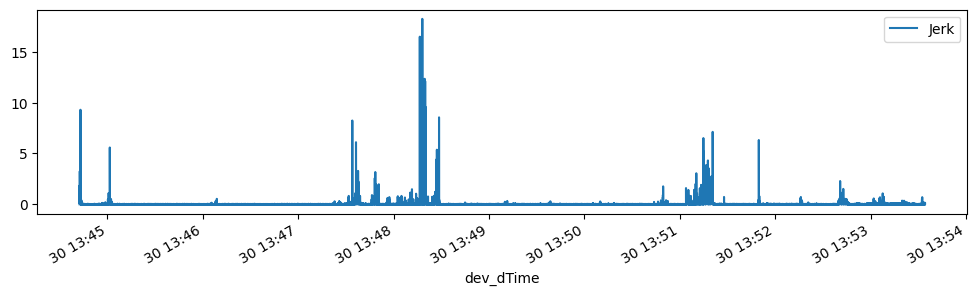

In [17]:
dt_0 = synch_times[c]-pd.to_timedelta(300,unit='s')
dt_1 = synch_times[c]+pd.to_timedelta(300,unit='s')
ACC_ex = al.dt_cut(V,'dev_dTime',dt_0,dt_1)
print(len(ACC_ex))
ACC_ex.plot(x='dev_dTime',y='Jerk',figsize=[12,3])

4082


<Axes: xlabel='dev_dTime'>

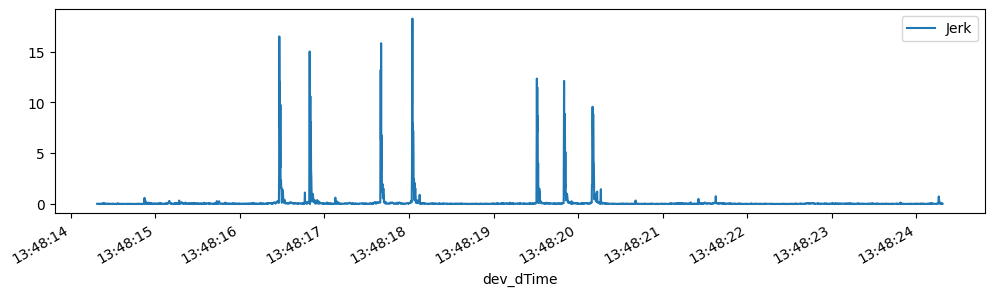

In [18]:
dt_0 = synch_times[c]-pd.to_timedelta(20,unit='s')
dt_1 = synch_times[c]+pd.to_timedelta(-10,unit='s')
ACC_ex = al.dt_cut(V,'dev_dTime',dt_0,dt_1)
print(len(ACC_ex))
ACC_ex.plot(x='dev_dTime',y='Jerk',figsize=[12,3])

In [27]:
to_dev_ts =  -18 # offset in seconds to get the cue closer to true time, incase that is necessary

2025-09-30 13:48:16.310385488


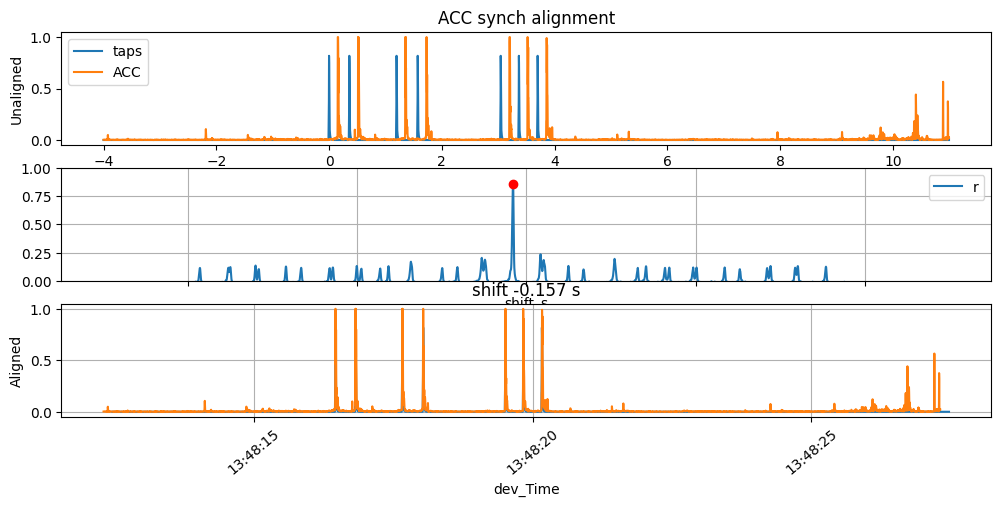

In [28]:
c = 'cue1'
cue = CueT[c].copy()
prelim_synch_time = (synch_times[c]+pd.to_timedelta(to_dev_ts,unit='s')).tz_localize(None)
print(prelim_synch_time)

c_type = 'taps'
results = al.min_align(V,c_type,CueT[c].copy(),prelim_synch_time,10)
Offsets.loc['dev_dt',c]=results['best_dt']

2025-09-30 14:57:56.153650794


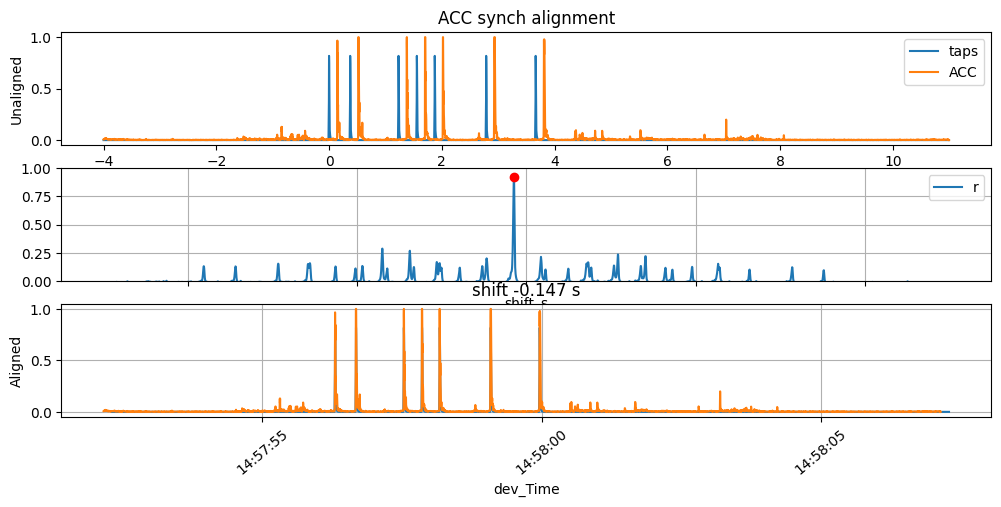

In [29]:
c = 'cue2'
cue = CueT[c].copy()
prelim_synch_time = (synch_times[c]+pd.to_timedelta(to_dev_ts,unit='s')).tz_localize(None)
print(prelim_synch_time)

c_type = 'taps'
results = al.min_align(V,c_type,CueT[c].copy(),prelim_synch_time,10)
Offsets.loc['dev_dt',c]=results['best_dt']

In [30]:
# calculate clock drift constant from the difference between the offsets to sync1 and sync 2
drift_C = (Offsets.loc['exp_dt','cue2']-Offsets.loc['exp_dt','cue1']).total_seconds()/(Offsets.loc['dev_dt','cue2']-Offsets.loc['dev_dt','cue1']).total_seconds()
print(drift_C)
# set zero to the start of the first sync cue
V['rec_sTime'] = 0 +np.round((V['dev_dTime']-Offsets.loc['dev_dt','cue1']).dt.total_seconds()*drift_C,3)
V['rec_dTime'] = pd.to_timedelta(V['rec_sTime'],unit='s')+ Offsets.loc['exp_dt','cue1']
V.iloc[:5,:]

1.000002392439929


,dev_dTime,X,Y,Z,dev_sTime,Jerk,rec_sTime,rec_dTime
0,2025-09-30 13:44:42.470,-0.703125,0.203125,0.781250,0.000,0.000000,-213.998,2025-09-30 13:45:00.312385488
1,2025-09-30 13:44:42.472,-0.015625,-0.109375,-0.906250,0.002,1.848775,-213.996,2025-09-30 13:45:00.314385488
2,2025-09-30 13:44:42.474,-0.015625,-0.125000,-0.984375,0.004,0.079672,-213.994,2025-09-30 13:45:00.316385488
3,2025-09-30 13:44:42.477,-0.015625,-0.125000,-0.984375,0.007,0.000000,-213.991,2025-09-30 13:45:00.319385488
4,2025-09-30 13:44:42.479,-0.015625,-0.125000,-0.984375,0.009,0.000000,-213.989,2025-09-30 13:45:00.321385488


## Save the new aligned time stamps for the whole file and for an excerpt

- Sync 1, 34.319 s, 13:48 local time
- clapper 1, 2437.788 s,
- Stimulus (applause), 2505.937s
- Stimulus (music), 2528.285
- Stimulus (applause 2), 2822.525
- clapper 2, 2850.388 s,
- clapper 3, 2853.664 s
- Sync 2, 4214.149 s

In [31]:
out_loc = '../Aligned/AX3/'

newfilename = files[dev_i][:5]+'_aligned.csv'
print(newfilename)
V.loc[:,['rec_sTime', 'X', 'Y', 'Z','rec_dTime','dev_dTime']].to_csv(out_loc + newfilename,index=True)

14357_aligned.csv


In [32]:
seg_loc = '../Excerpt/AX3/'

excerpt_start = 2437.788 - 34.319 # time since first sync cue started, the recording time zero
excerpt_end = 2853.664 - 34.319 # time since first sync cue started, the recording time zero
seg = V.query('rec_sTime>@excerpt_start and rec_sTime<@excerpt_end').copy()
seg['p_sTime'] = seg['rec_sTime']-excerpt_start

newfilename = files[dev_i][:5]+'_Seg_aligned.csv'
print(newfilename)
seg.loc[:,['p_sTime', 'X', 'Y', 'Z','rec_sTime','rec_dTime','dev_dTime']].to_csv(seg_loc + newfilename,index=True)      

14357_Seg_aligned.csv


The above sequence can be condensed to run automatically across selected files. Going one at a time is helpful with devices that are more variable than the AX3s. Still it's good to check that the cue template has correctly aligned with the measurements.

# Confirm corrected time stamps and produce a csv of simultaneous measurement values across all devices.

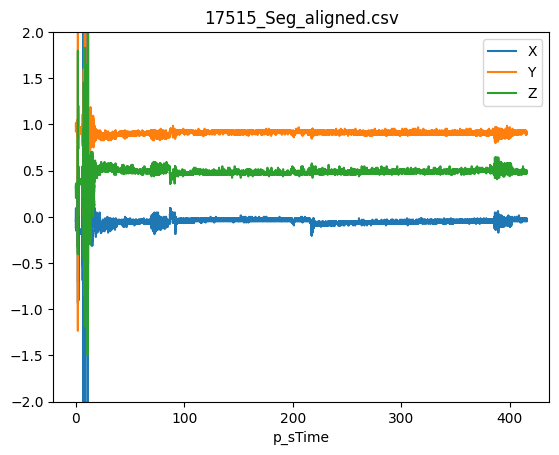

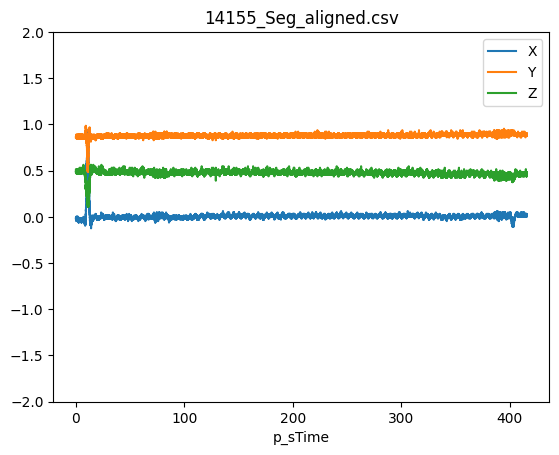

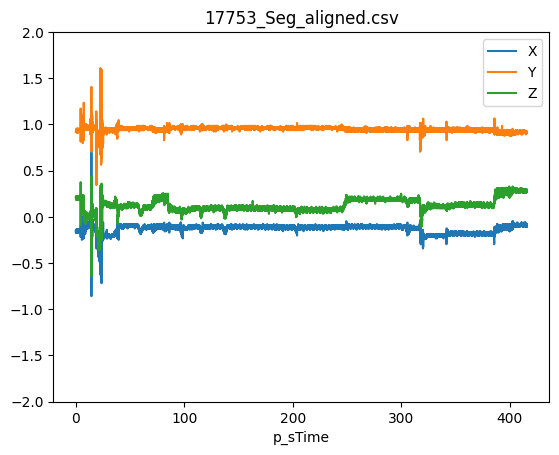

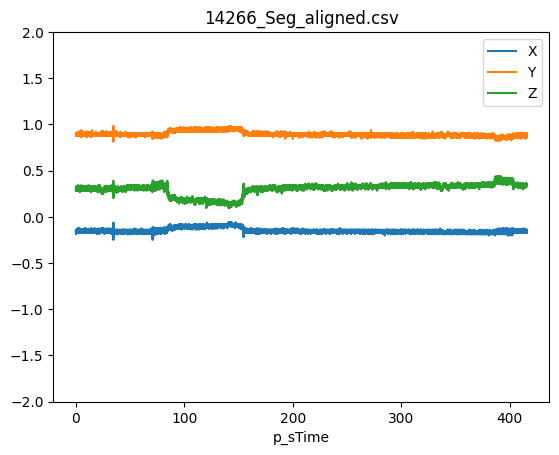

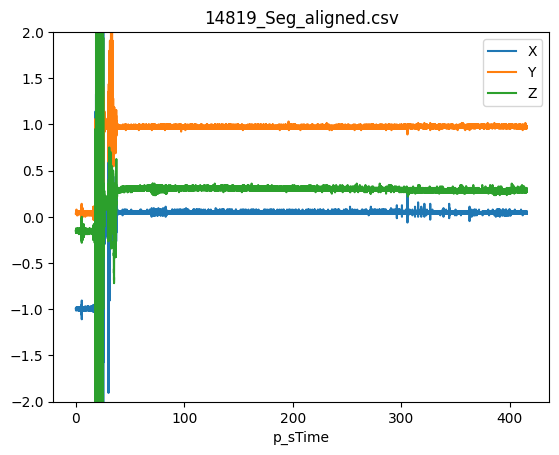

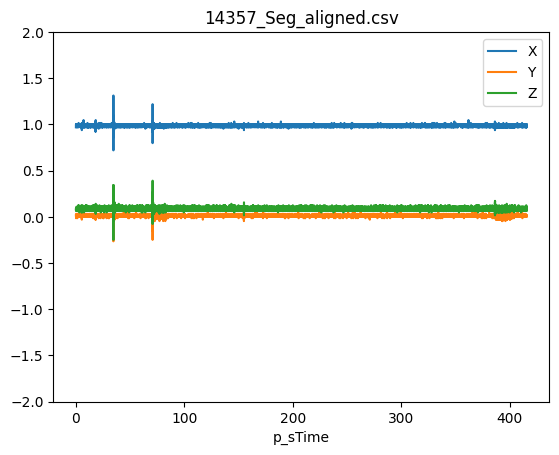

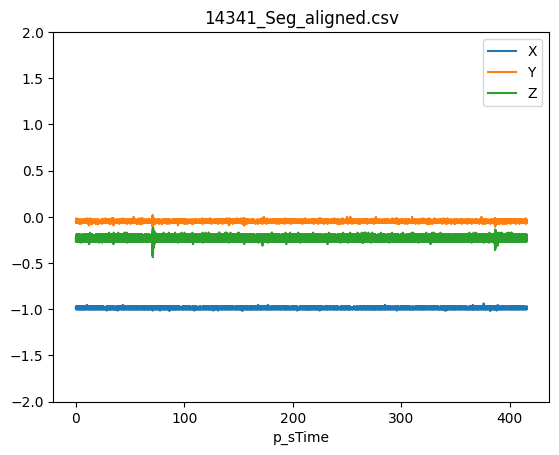

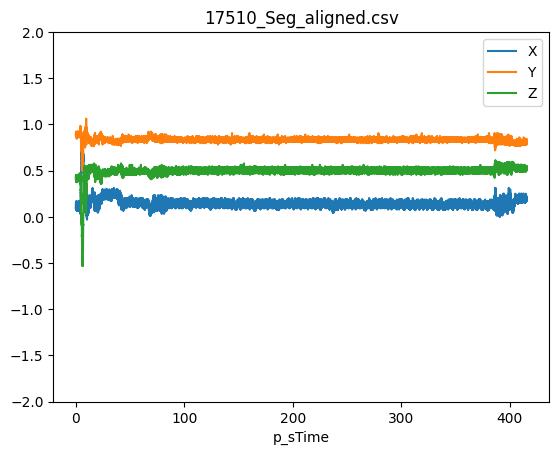

In [6]:
fileloc = '../Excerpt/AX3/'

files = os.listdir(fileloc)

for f in files:
    df_acc = pd.read_csv(fileloc+f,index_col=0)
    df_acc.set_index('p_sTime',drop=True,inplace=True)
    df_acc.loc[:,['X', 'Y', 'Z',]].plot()
    plt.title(f)
    plt.ylim([-2,2])
    plt.show()

In [7]:
fileloc = '../Excerpt/AX3/'
ax3s={'AU1':'14155_Seg_aligned.csv',
 'AU2':'17510_Seg_aligned.csv',
 'AU3':'17515_Seg_aligned.csv',
 'AU4':'17753_Seg_aligned.csv',
 'AU5':'14819_Seg_aligned.csv',
 'AU7':'14266_Seg_aligned.csv',}
fs = 400
alt_fs = 10
time_s = np.arange(0.005,415.875,1/fs)
time_salt = np.arange(0.005,415.875,1/alt_fs)

datapath = '/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/Naive/'
fileName = 'motion_normalized_roi_sizes.csv'

Accelerometer signals often need lowpass filtering just from sensor noise. For these analyses, we looks at signals at different time resolutions, so here we output version of the ACC measurements with different fliters. 50 Hz cutoff for high frequency actions like clapping analysis, 10 Hz for Jerk magnitude on big guestures like body movement and full recording comparisions with camera based QoM.


In [8]:
#initial lowpass filtering 
fs=400
filtering_range = 25 
cutoff = np.array(filtering_range) #cutoff = np.array([0.05,1]) 
nyq = 0.5 * fs 
order = 2 
normal_cutoff = cutoff / nyq
b50, a50 = butter(order, normal_cutoff, btype='lowpass', analog=False)

In [9]:
#initial lowpass filtering 
filtering_range = 10 #5 hz for 10 hz sampling 
cutoff = np.array(filtering_range) #cutoff = np.array([0.05,1]) 
nyq = 0.5 * fs 
order = 2 
normal_cutoff = cutoff / nyq
b10, a10 = butter(order, normal_cutoff, btype='lowpass', analog=False)

In [10]:
# magnitudes on ACC and Jerk without downsampling or filtering
QoM = pd.DataFrame(index = time_s,columns = ax3s.keys())
jerks= pd.DataFrame(index = time_s,columns = ax3s.keys())
for PartID in ax3s.keys():
    df_acc = pd.read_csv(fileloc+ax3s[PartID],index_col=1)
    acc = np.sqrt((df_acc['X']**2)+(df_acc['Y']**2)+(df_acc['Z']**2))
    jerk = np.sqrt(np.square(df_acc.loc[:,['X','Y','Z']].diff()).sum(axis=1))

    f = interp1d(acc.index,acc.values)
    QoM.loc[:,PartID]=f(time_s)
    f = interp1d(jerk.index,jerk.values)
    jerks.loc[:,PartID]=f(time_s)
QoM.loc[:,'timestamp'] = time_s
jerks.loc[:,'timestamp'] = time_s

QoM.to_csv(datapath + 'ax3/'+fileName,index=False)
jerks.to_csv(datapath + 'jerk/'+fileName,index=False)


In [11]:
filtacc = pd.DataFrame(index = time_s,columns = ax3s.keys())
jerks= pd.DataFrame(index = time_s,columns = ax3s.keys())
filtacc_alt = pd.DataFrame(index = time_salt,columns = ax3s.keys()) 
jerks_alt= pd.DataFrame(index = time_salt,columns = ax3s.keys())
acc_dim =pd.DataFrame(index = time_s)
for PartID in ax3s.keys():
    df_acc = pd.read_csv(fileloc+ax3s[PartID],index_col=1)
    acc_f50 = pd.DataFrame(index=time_s,columns = ['X', 'Y', 'Z'],dtype="float") # I can't believe I need to specify this wtf pandas why
    acc_s10 = pd.DataFrame(index=time_salt,columns = ['X', 'Y', 'Z'],dtype="float") # I can't believe I need to specify this wtf pandas why
    acc_mid = acc_f50.copy() 
    for col in ['X', 'Y', 'Z']:
        f = interp1d(df_acc.index,df_acc[col]) # 
        #each dimension resampled to 400 Hz and lowpass filtered 50
        acc_dim.loc[:,PartID + '_'+col]=filtfilt(b50, a50, f(time_s))
        # same but for magnitude reduction
        acc_f50.loc[:,col]=filtfilt(b50, a50, f(time_s))
        # from magnitude reduction on 10 Hz sampled data
        acc_mid.loc[:,col]=filtfilt(b10, a10, f(time_s))
        f = interp1d(acc_mid.index,acc_mid[col]) # 
        acc_s10.loc[:,col]=f(time_salt) 
    # magnitude of acceleration at 400 Hz, filtered to 50 Hz   
    filtacc.loc[:,PartID] = np.sqrt((acc_f50['X']**2)+(acc_f50['Y']**2)+(acc_f50['Z']**2))
    # magnitude of Jerk at 400 Hz, filtered to 50 Hz   
    jerks.loc[:,PartID] = np.sqrt(np.square(acc_f50.loc[:,['X','Y','Z']].diff()).sum(axis=1))
    # magnitude of acceleration at 10 Hz, filtered to 5 Hz   
    filtacc_alt.loc[:,PartID] = np.sqrt((acc_s10['X']**2)+(acc_s10['Y']**2)+(acc_s10['Z']**2))
    # magnitude of Jerk at 10 Hz, filtered to 5 Hz   
    jerks_alt.loc[:,PartID] = np.sqrt(np.square(acc_s10.loc[:,['X','Y','Z']].diff()).sum(axis=1))

filtacc.loc[:,'timestamp'] = time_s
jerks.loc[:,'timestamp'] = time_s
acc_dim.loc[:,'timestamp'] = time_s
jerks_alt.loc[:,'timestamp'] = time_salt
filtacc_alt.loc[:,'timestamp'] = time_salt

filtacc.to_csv(datapath + 'filt_acc/'+fileName,index=False)
jerks.to_csv(datapath + 'filt_jerk/'+fileName,index=False)
filtacc_alt.to_csv(datapath + 'filt_acc10Hz/'+fileName,index=False)
jerks_alt.to_csv(datapath + 'filt_jerk10Hz/'+fileName,index=False)
acc_dim.to_csv(datapath + 'acc_dim/'+fileName,index=False)


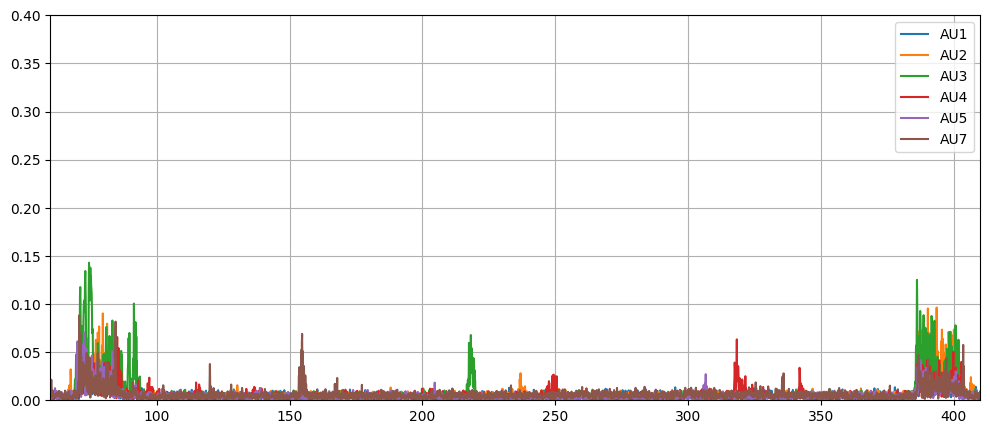

In [12]:
# jerks_alt.iloc[:,:-1].plot(figsize=(12,4+1),)
plt.xlim([60,410])
plt.ylim([0,0.4])
plt.grid()

In [54]:
datapath + 'filt_jerk10Hz'

'/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/Naive/filt_jerk10Hz'